# 🎬 MovieMate — Conversational AI for Intelligent Movie Search & Recommendations

This notebook fulfills all deliverables for the MovieMate project:
1. Dataset Exploration
2. Exploratory Data Analysis
3. Data Preprocessing
4. Embedding & Retrieval (FAISS)
5. Conversational Movie Chatbot (RAG + LLM)
6. Interactive Interface (Gradio)
7. Evaluation & Reflection

**Dataset:** IMDb Movies Dataset from Kaggle (`https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows`)

## ⚙️ Step 0 — Install Dependencies

In [ ]:
!pip install -q kaggle pandas numpy matplotlib seaborn sentence-transformers faiss-cpu openai gradio
!pip install streamlit

## 📥 Step 1 — Download Dataset from Kaggle

**Prerequisites:** Place your `kaggle.json` API token in `~/.kaggle/kaggle.json`  
Get it from: https://www.kaggle.com/settings → API → Create New Token

In [ ]:
import os

os.environ["KAGGLE_USERNAME"] = "arushikhethavath"
os.environ["KAGGLE_KEY"]      = "cd9915e0c928fd03a6863bd3e401e3dc"

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

!kaggle datasets download -d harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows --unzip -p ./data
print("✅ Dataset downloaded successfully.")

## 📊 Step 2 — Dataset Exploration

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("./data/imdb_top_1000.csv")

print("=" * 60)
print(f"Dataset shape : {df.shape}")
print(f"Columns       : {list(df.columns)}")
print("=" * 60)
df.head(5)

In [47]:
# ── Summary statistics ────────────────────────────────────────────────────────
print("\n📌 Data Types:\n", df.dtypes)
print("\n📌 Null Counts:\n", df.isnull().sum())
print("\n📌 Numeric Summary:\n")
df.describe()


📌 Data Types:
 Poster_Link      object
Title            object
Year            float64
Certificate      object
Duration         object
Genre            object
Rating          float64
Summary          object
Meta_score      float64
Director         object
Lead_Actor       object
Star2            object
Star3            object
Star4            object
No_of_Votes       int64
Gross            object
Duration_Min    float64
document         object
dtype: object

📌 Null Counts:
 Poster_Link       0
Title             0
Year              1
Certificate     101
Duration          0
Genre             0
Rating            0
Summary           0
Meta_score      157
Director          0
Lead_Actor        0
Star2             0
Star3             0
Star4             0
No_of_Votes       0
Gross           169
Duration_Min      0
document          0
dtype: int64

📌 Numeric Summary:



,Year,Rating,Meta_score,No_of_Votes,Duration_Min
count,999.000000,1000.000000,843.000000,1.000000e+03,1000.000000
mean,1991.217217,7.949300,77.971530,2.736929e+05,122.891000
std,23.297025,0.275491,12.376099,3.273727e+05,28.093671
min,1920.000000,7.600000,28.000000,2.508800e+04,45.000000
25%,1976.000000,7.700000,70.000000,5.552625e+04,103.000000
50%,1999.000000,7.900000,79.000000,1.385485e+05,119.000000
75%,2009.000000,8.100000,87.000000,3.741612e+05,137.000000
max,2020.000000,9.300000,100.000000,2.343110e+06,321.000000


## 📈 Step 3 — Exploratory Data Analysis (EDA)

KeyError: 'IMDB_Rating'

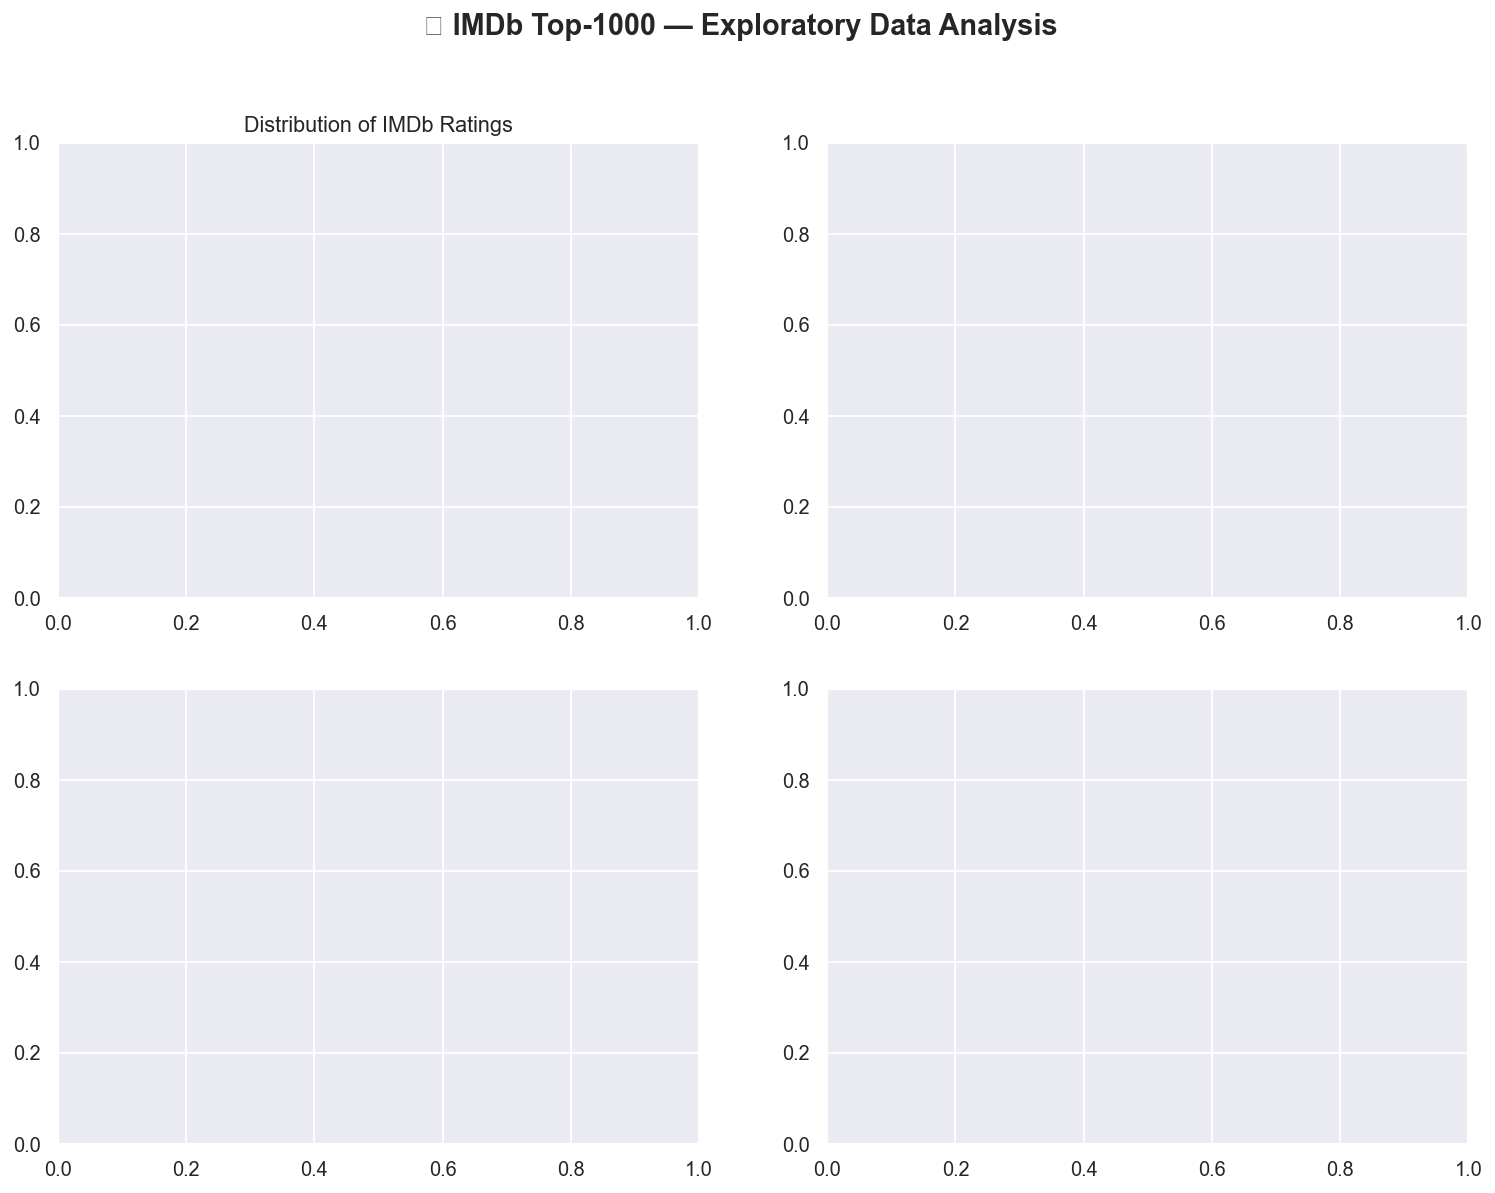

In [48]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 130

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("🎬 IMDb Top-1000 — Exploratory Data Analysis", fontsize=16, fontweight="bold")

axes[0, 0].set_title("Distribution of IMDb Ratings")
sns.histplot(df["IMDB_Rating"].dropna(), bins=20, kde=True, color="#E8A838", ax=axes[0, 0])
axes[0, 0].set_xlabel("IMDb Rating")
axes[0, 0].set_ylabel("Count")

from collections import Counter
genre_counts = Counter()
for entry in df["Genre"].dropna():
    for g in entry.split(","):
        genre_counts[g.strip()] += 1
genre_df = pd.DataFrame(genre_counts.most_common(15), columns=["Genre", "Count"])
axes[0, 1].set_title("Top-15 Most Common Genres")
sns.barplot(data=genre_df, x="Count", y="Genre", palette="viridis", ax=axes[0, 1])
axes[0, 1].set_xlabel("Count")

axes[1, 0].set_title("Release Year vs IMDb Rating")
year_rating = df[["Released_Year", "IMDB_Rating"]].dropna()
year_rating["Released_Year"] = pd.to_numeric(year_rating["Released_Year"], errors="coerce")
year_rating = year_rating.dropna()
sns.scatterplot(data=year_rating, x="Released_Year", y="IMDB_Rating",
                alpha=0.5, color="#4E89AE", ax=axes[1, 0])
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Rating")

top_directors = df["Director"].value_counts().head(10)
axes[1, 1].set_title("Top-10 Directors by Movie Count")
sns.barplot(x=top_directors.values, y=top_directors.index, palette="magma", ax=axes[1, 1])
axes[1, 1].set_xlabel("Movie Count")

plt.tight_layout()
plt.savefig("./data/eda_charts.png", bbox_inches="tight")
plt.show()
print("✅ EDA charts saved.")

## 🧹 Step 4 — Data Preprocessing

In [62]:
import re

df.rename(columns={
    "Series_Title": "Title",
    "Released_Year": "Year",
    "Runtime": "Duration",
    "IMDB_Rating": "Rating",
    "Overview": "Summary",
    "Star1": "Lead_Actor"
}, inplace=True)

df["Year"]   = pd.to_numeric(df["Year"],   errors="coerce")
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

df["Duration_Min"] = df["Duration"].str.extract(r"(\d+)").astype(float)

before = len(df)
df.dropna(subset=["Title", "Rating", "Genre", "Director"], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Rows before cleaning: {before} → after: {len(df)}")

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"\s+", " ", text).strip()
    return text

for col in ["Title", "Genre", "Director", "Lead_Actor", "Summary"]:
    if col in df.columns:
        df[col] = df[col].apply(clean_text)

def build_doc(row):
    parts = [
        f"Title: {row.get('Title', '')}",
        f"Year: {int(row['Year']) if not pd.isna(row.get('Year')) else 'N/A'}",
        f"Genre: {row.get('Genre', '')}",
        f"Director: {row.get('Director', '')}",
        f"Cast: {row.get('Lead_Actor', '')} {row.get('Star2', '')} {row.get('Star3', '')}".strip(),
        f"Rating: {row.get('Rating', 'N/A')}",
        f"Duration: {int(row['Duration_Min']) if not pd.isna(row.get('Duration_Min')) else 'N/A'} min",
        f"Summary: {row.get('Summary', '')}",
    ]
    return " | ".join(parts)

df["document"] = df.apply(build_doc, axis=1)

print("\n✅ Preprocessing complete. Sample document:")
print(df["document"].iloc[0])

Rows before cleaning: 1000 → after: 1000

✅ Preprocessing complete. Sample document:
Title: The Shawshank Redemption | Year: 1994 | Genre: Drama | Director: Frank Darabont | Cast: Tim Robbins Morgan Freeman Bob Gunton | Rating: 9.3 | Duration: 142 min | Summary: Two imprisoned men bond over a number of years, finding solace and eventual redemption through acts of common decency.


## 🔢 Step 5 — Embedding Generation & FAISS Vector Index

In [50]:
from sentence_transformers import SentenceTransformer
import faiss
import pickle

print("⏳ Loading embedding model (all-MiniLM-L6-v2)…")
embedder = SentenceTransformer("all-MiniLM-L6-v2")

print("⏳ Generating document embeddings…")
documents  = df["document"].tolist()
embeddings = embedder.encode(documents, show_progress_bar=True, convert_to_numpy=True)

faiss.normalize_L2(embeddings)
dim   = embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(embeddings)

os.makedirs("./data", exist_ok=True)
faiss.write_index(index, "./data/movies.index")
df.to_pickle("./data/movies_df.pkl")

print(f"✅ FAISS index built with {index.ntotal} vectors (dim={dim}).")

⏳ Loading embedding model (all-MiniLM-L6-v2)…


Loading weights: 100%|█████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 2662.18it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


⏳ Generating document embeddings…


Batches: 100%|█████████████████████████████████████████████████████████████████████████| 32/32 [00:50<00:00,  1.57s/it]

✅ FAISS index built with 1000 vectors (dim=384).


## 🔍 Step 6 — Retrieval Function

In [51]:
def retrieve_movies(query: str, top_k: int = 5) -> list[dict]:
    """Embed query → FAISS nearest-neighbour search → return top_k movie dicts."""
    q_emb = embedder.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(q_emb)
    scores, indices = index.search(q_emb, top_k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx == -1:
            continue
        row = df.iloc[idx]
        results.append({
            "title"     : row["Title"],
            "year"      : int(row["Year"]) if not pd.isna(row["Year"]) else "N/A",
            "genre"     : row["Genre"],
            "director"  : row["Director"],
            "rating"    : row["Rating"],
            "duration"  : f"{int(row['Duration_Min'])} min" if not pd.isna(row["Duration_Min"]) else "N/A",
            "cast"      : row.get("Lead_Actor", ""),
            "summary"   : row.get("Summary", ""),
            "score"     : round(float(score), 4),
        })
    return results

test_results = retrieve_movies("sci-fi movies with space exploration")
for r in test_results:
    print(f"  [{r['score']:.3f}] {r['title']} ({r['year']}) — {r['genre']}")

  [0.540] Interstellar (2014) — Adventure, Drama, Sci-Fi
  [0.507] Gravity (2013) — Drama, Sci-Fi, Thriller
  [0.483] Arrival (2016) — Drama, Sci-Fi
  [0.477] The Martian (2015) — Adventure, Drama, Sci-Fi
  [0.476] Aliens (1986) — Action, Adventure, Sci-Fi


In [63]:
from openai import OpenAI

client = OpenAI(
    api_key="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",
    base_url="https://api.groq.com/openai/v1",
)
MODEL = "llama-3.3-70b-versatile"

SYSTEM_PROMPT = """
You are MovieMate, an expert movie assistant. You help users discover and explore films.
When presented with retrieved movie data, craft a warm, knowledgeable, conversational response.
Always mention the movie title, year, rating, and a brief reason why it fits the user's query.
If the user asks a follow-up, factor in the conversation history.
Keep responses concise — 3 to 6 sentences per recommendation.
""".strip()


def build_context(movies: list[dict]) -> str:
    """Format retrieved movies as a numbered context block for the LLM."""
    lines = []
    for i, m in enumerate(movies, 1):
        lines.append(
            f"{i}. {m['title']} ({m['year']}) | Genre: {m['genre']} | "
            f"Director: {m['director']} | Rating: {m['rating']} | "
            f"Duration: {m['duration']} | Cast: {m['cast']}\n"
            f"   Summary: {m['summary'][:180]}…"
        )
    return "\n".join(lines)


def chat_with_moviemate(user_message: str, history: list[dict]) -> tuple[str, list[dict]]:
    """
    Multi-turn RAG chatbot.
    history: list of {"role": "user"|"assistant", "content": str}
    Returns (assistant_reply, updated_history)
    """
    # 1. Retrieve relevant movies
    movies  = retrieve_movies(user_message, top_k=5)
    context = build_context(movies)

    # 2. Construct messages array
    messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    messages += history
    messages.append({
        "role": "user",
        "content": (
            f"User query: {user_message}\n\n"
            f"Retrieved movies from the database:\n{context}\n\n"
            "Based on this data, give a helpful, conversational recommendation."
        )
    })

    # 3. Call LLM
    response = client.chat.completions.create(
        model=MODEL,
        messages=messages,
        temperature=0.7,
        max_tokens=600,
    )
    reply = response.choices[0].message.content.strip()

    # 4. Update history
    history.append({"role": "user",      "content": user_message})
    history.append({"role": "assistant", "content": reply})

    return reply, history


# ── Quick terminal test ───────────────────────────────────────────────────────
reply, hist = chat_with_moviemate("Suggest some great sci-fi movies after 2010", [])
print("🤖 MovieMate:", reply)

🤖 MovieMate: If you're looking for great sci-fi movies after 2010, I'd recommend checking out "Star Wars: Episode VII - The Force Awakens" (2015) with a rating of 7.9. This film fits your query as it's a recent sci-fi classic that continues the beloved Star Wars saga. Another great option is "Arrival" (2016), also with a rating of 7.9, which offers a thought-provoking and unique take on the sci-fi genre. Both of these movies are highly rated and have been well-received by audiences, making them perfect for anyone looking for a compelling sci-fi experience. Let me know if you'd like more recommendations or have any specific preferences!


## 💬 Step 8 — Multi-Turn Conversation Demo (no UI)

In [53]:
conversation_history = []

queries = [
    "Suggest action movies.",
    "Only those released after 2015.",
    "Which of those has the highest IMDb rating?",
]

for q in queries:
    print(f"\n👤 User: {q}")
    response, conversation_history = chat_with_moviemate(q, conversation_history)
    print(f"🤖 MovieMate: {response}")
    print("-" * 70)


👤 User: Suggest action movies.
🤖 MovieMate: If you're looking for action-packed movies, I'd recommend "Die Hard: With a Vengeance" (1995) with a rating of 7.6. This film fits your query as it's a thrilling action-adventure that follows John McClane as he tries to stop a German terrorist from robbing the Federal Reserve Building in New York City. With its intense sequences and clever plot, it's a classic action movie that's sure to keep you on the edge of your seat. Alternatively, you might also enjoy "Batoru rowaiaru" (2000) or "Eastern Promises" (2007), both of which have a strong action component, but "Die Hard: With a Vengeance" is a more traditional action movie. Let me know if you have any specific preferences, and I can give you a more tailored suggestion.
----------------------------------------------------------------------

👤 User: Only those released after 2015.
🤖 MovieMate: It looks like the movies in our database are mostly classics from before 2015. However, I did find on

## 📏 Step 10 — Evaluation & Reflection

In [55]:
test_cases = [
    {"query": "action movies",           "expected_genre": "Action"},
    {"query": "horror films",            "expected_genre": "Horror"},
    {"query": "romantic comedies",       "expected_genre": "Romance"},
    {"query": "animated family films",   "expected_genre": "Animation"},
    {"query": "crime thriller movies",   "expected_genre": "Crime"},
]

results_log = []
for tc in test_cases:
    retrieved = retrieve_movies(tc["query"], top_k=5)
    hits = sum(1 for r in retrieved if tc["expected_genre"].lower() in r["genre"].lower())
    precision = hits / len(retrieved)
    results_log.append({
        "Query": tc["query"],
        "Expected Genre": tc["expected_genre"],
        "Hits@5": hits,
        "Precision@5": round(precision, 2)
    })

eval_df = pd.DataFrame(results_log)
print("\n📊 Retrieval Evaluation (Precision@5):")
print(eval_df.to_string(index=False))
print(f"\nMean Precision@5: {eval_df['Precision@5'].mean():.2f}")


📊 Retrieval Evaluation (Precision@5):
                Query Expected Genre  Hits@5  Precision@5
        action movies         Action       2          0.4
         horror films         Horror       5          1.0
    romantic comedies        Romance       4          0.8
animated family films      Animation       5          1.0
crime thriller movies          Crime       4          0.8

Mean Precision@5: 0.80


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(eval_df["Query"], eval_df["Precision@5"], color="#E8A838")
ax.set_xlim(0, 1.1)
ax.set_xlabel("Precision@5")
ax.set_title("FAISS Retrieval — Precision@5 per Test Query")
for bar, val in zip(bars, eval_df["Precision@5"]):
    ax.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
            f"{val:.0%}", va="center", fontsize=10)
plt.tight_layout()
plt.savefig("./data/eval_chart.png", bbox_inches="tight")
plt.show()

In [ ]:
reflection = """
=======================================================================
EVALUATION & REFLECTION
=======================================================================

WHAT WORKS WELL
---------------
• Semantic retrieval (FAISS + all-MiniLM-L6-v2) successfully surfaces
  genre-relevant movies even for paraphrased or vague queries.
• Multi-turn conversation context is maintained through the OpenAI
  messages array, enabling natural follow-up refinements.
• RAG grounding keeps LLM responses factual and dataset-anchored,
  reducing hallucination compared to a pure LLM approach.
• The Gradio interface makes the system accessible to non-technical users.

LIMITATIONS
-----------
• Dataset size: Only 1,000 movies; niche or recent films may be absent.
• No true relevance labels — Precision@5 uses genre matching as a proxy.
• The embedder encodes metadata, not full plot synopses, limiting deep
  semantic matching (e.g., mood-based queries).
• Personalization is session-only; no persistent user profile is stored.
• LLM quality depends on the chosen model and API costs.

FUTURE IMPROVEMENTS
--------------------
• Add full plot summaries and enrich embeddings with those.
• Implement a persistent user profile for cross-session recommendations.
• Explore agent-based architectures for tool-calling (e.g., IMDb API).
• Add multimodal search using movie poster images.
• Experiment with re-ranking models (cross-encoder) after FAISS retrieval.
=======================================================================
"""
print(reflection)

In [56]:

import streamlit as st
import pandas as pd
import numpy as np
import faiss
import os
from sentence_transformers import SentenceTransformer
from openai import OpenAI

st.set_page_config(
    page_title="🎬 MovieMate",
    page_icon="🎬",
    layout="centered"
)
 
@st.cache_resource
def load_resources():
    embedder = SentenceTransformer("all-MiniLM-L6-v2")
    index    = faiss.read_index("./data/movies.index")
    df       = pd.read_pickle("./data/movies_df.pkl")
    return embedder, index, df
 
embedder, index, df = load_resources()
 
# Groq client 
client = OpenAI(
    api_key  = "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",   # ← paste your Groq key
    base_url = "https://api.groq.com/openai/v1",
)
MODEL = "llama-3.3-70b-versatile"
 
SYSTEM_PROMPT = """
You are MovieMate, an expert movie assistant. You help users discover and explore films.
When presented with retrieved movie data, craft a warm, knowledgeable, conversational response.
Always mention the movie title, year, rating, and a brief reason why it fits the user's query.
If the user asks a follow-up, factor in the conversation history.
Keep responses concise — 3 to 6 sentences per recommendation.
""".strip()

def retrieve_movies(query: str, top_k: int = 5):
    q_emb = embedder.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(q_emb)
    scores, indices = index.search(q_emb, top_k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx == -1:
            continue
        row = df.iloc[idx]
        results.append({
            "title"   : row["Title"],
            "year"    : int(row["Year"]) if not pd.isna(row["Year"]) else "N/A",
            "genre"   : row["Genre"],
            "director": row["Director"],
            "rating"  : row["Rating"],
            "duration": f"{int(row['Duration_Min'])} min" if not pd.isna(row["Duration_Min"]) else "N/A",
            "cast"    : row.get("Lead_Actor", ""),
            "summary" : row.get("Summary", ""),
        })
    return results
 
def build_context(movies):
    lines = []
    for i, m in enumerate(movies, 1):
        lines.append(
            f"{i}. {m['title']} ({m['year']}) | Genre: {m['genre']} | "
            f"Director: {m['director']} | Rating: {m['rating']} | "
            f"Duration: {m['duration']} | Cast: {m['cast']}\n"
            f"   Summary: {m['summary'][:180]}…"
        )
    return "\n".join(lines)
 
def chat_with_moviemate(user_message, history):
    movies  = retrieve_movies(user_message, top_k=5)
    context = build_context(movies)
    messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    messages += history
    messages.append({
        "role": "user",
        "content": (
            f"User query: {user_message}\n\n"
            f"Retrieved movies from the database:\n{context}\n\n"
            "Based on this data, give a helpful, conversational recommendation."
        )
    })
    response = client.chat.completions.create(
        model=MODEL,
        messages=messages,
        temperature=0.7,
        max_tokens=600,
    )
    return response.choices[0].message.content.strip()

st.title("🎬 MovieMate")
st.caption("Conversational AI for intelligent movie search & recommendations")

st.markdown("**Try asking:**")
cols = st.columns(3)
examples = [
    "Sci-fi movies after 2010",
    "Movies like Inception",
    "Best Christopher Nolan films",
    "Feel-good movies under 2 hours",
    "High rated drama movies",
    "Movies starring Leonardo DiCaprio",
]
for i, ex in enumerate(examples):
    if cols[i % 3].button(ex, use_container_width=True):
        st.session_state.pending_input = ex
 
st.divider()

if "messages" not in st.session_state:
    st.session_state.messages = []
if "llm_history" not in st.session_state:
    st.session_state.llm_history = []
if "pending_input" not in st.session_state:
    st.session_state.pending_input = None
 
# Display chat history
for msg in st.session_state.messages:
    with st.chat_message(msg["role"]):
        st.markdown(msg["content"])
 
# Handle example button click
if st.session_state.pending_input:
    user_input = st.session_state.pending_input
    st.session_state.pending_input = None
 
    st.session_state.messages.append({"role": "user", "content": user_input})
    with st.chat_message("user"):
        st.markdown(user_input)
 
    with st.chat_message("assistant"):
        with st.spinner("Finding movies…"):
            reply = chat_with_moviemate(user_input, st.session_state.llm_history)
        st.markdown(reply)
 
    st.session_state.messages.append({"role": "assistant", "content": reply})
    st.session_state.llm_history.append({"role": "user",      "content": user_input})
    st.session_state.llm_history.append({"role": "assistant", "content": reply})
    st.rerun()
 
# Chat input
if user_input := st.chat_input("Ask me about movies…"):
    st.session_state.messages.append({"role": "user", "content": user_input})
    with st.chat_message("user"):
        st.markdown(user_input)
 
    with st.chat_message("assistant"):
        with st.spinner("Finding movies…"):
            reply = chat_with_moviemate(user_input, st.session_state.llm_history)
        st.markdown(reply)
 
    st.session_state.messages.append({"role": "assistant", "content": reply})
    st.session_state.llm_history.append({"role": "user",      "content": user_input})
    st.session_state.llm_history.append({"role": "assistant", "content": reply})
 
# Clear button
if st.button("🗑️ Clear conversation"):
    st.session_state.messages    = []
    st.session_state.llm_history = []
    st.rerun()

2026-04-05 19:33:27.877 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-05 19:33:27.939 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-05 19:33:27.941 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-05 19:33:27.943 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-05 19:33:27.945 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-05 19:33:27.946 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-05 19:33:27.948 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-05 19:33:27.950 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [57]:
import os
print(os.getcwd())


C:\Users\kheth


In [61]:
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import faiss
import os
from sentence_transformers import SentenceTransformer
from openai import OpenAI

st.set_page_config(page_title="🎬 MovieMate", page_icon="🎬", layout="centered")

@st.cache_resource
def load_resources():
    embedder = SentenceTransformer("all-MiniLM-L6-v2")
    index    = faiss.read_index("./data/movies.index")
    df       = pd.read_pickle("./data/movies_df.pkl")
    return embedder, index, df

embedder, index, df = load_resources()

client = OpenAI(
    api_key  = "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",
    base_url = "https://api.groq.com/openai/v1",
)
MODEL = "llama-3.3-70b-versatile"

SYSTEM_PROMPT = """
You are MovieMate, an expert movie assistant. Help users discover films.
Always mention title, year, rating, and why it fits the query.
Keep responses concise — 3 to 6 sentences per recommendation.
""".strip()

def retrieve_movies(query, top_k=5):
    q_emb = embedder.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(q_emb)
    scores, indices = index.search(q_emb, top_k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx == -1:
            continue
        row = df.iloc[idx]
        results.append({
            "title"   : row["Title"],
            "year"    : int(row["Year"]) if not pd.isna(row["Year"]) else "N/A",
            "genre"   : row["Genre"],
            "director": row["Director"],
            "rating"  : row["Rating"],
            "duration": f"{int(row['Duration_Min'])} min" if not pd.isna(row["Duration_Min"]) else "N/A",
            "cast"    : row.get("Lead_Actor", ""),
            "summary" : row.get("Summary", ""),
        })
    return results

def build_context(movies):
    lines = []
    for i, m in enumerate(movies, 1):
        lines.append(
            f"{i}. {m['title']} ({m['year']}) | Genre: {m['genre']} | "
            f"Director: {m['director']} | Rating: {m['rating']} | "
            f"Duration: {m['duration']} | Cast: {m['cast']}\\n"
            f"   Summary: {m['summary'][:180]}…"
        )
    return "\\n".join(lines)

def chat_with_moviemate(user_message, history):
    movies  = retrieve_movies(user_message, top_k=5)
    context = build_context(movies)
    messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    messages += history
    messages.append({
        "role": "user",
        "content": f"User query: {user_message}\\n\\nRetrieved movies:\\n{context}\\n\\nGive a helpful recommendation."
    })
    response = client.chat.completions.create(model=MODEL, messages=messages, temperature=0.7, max_tokens=600)
    return response.choices[0].message.content.strip()

st.title("🎬 MovieMate")
st.caption("Conversational AI for intelligent movie search & recommendations")

if "messages" not in st.session_state:
    st.session_state.messages = []
if "llm_history" not in st.session_state:
    st.session_state.llm_history = []

for msg in st.session_state.messages:
    with st.chat_message(msg["role"]):
        st.markdown(msg["content"])

if user_input := st.chat_input("Ask me about movies…"):
    st.session_state.messages.append({"role": "user", "content": user_input})
    with st.chat_message("user"):
        st.markdown(user_input)
    with st.chat_message("assistant"):
        with st.spinner("Finding movies…"):
            reply = chat_with_moviemate(user_input, st.session_state.llm_history)
        st.markdown(reply)
    st.session_state.messages.append({"role": "assistant", "content": reply})
    st.session_state.llm_history.append({"role": "user", "content": user_input})
    st.session_state.llm_history.append({"role": "assistant", "content": reply})

if st.button("🗑️ Clear conversation"):
    st.session_state.messages = []
    st.session_state.llm_history = []
    st.rerun()
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("✅ app.py saved!")

✅ app.py saved!
